In [214]:
%load_ext autoreload
import torch

_printed_once_set = set()
def dedup_print(*args, key=None, once=True, **kwargs):
    if once:
        k = key if key is not None else ' '.join(map(str, args))
        if k in _printed_once_set:
            return
        _printed_once_set.add(k)
    print(*args, **kwargs)

dedup_print("Torch Version:", torch.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    dedup_print("Torch CUDA Available:", torch.cuda.is_available())
    torch.rand(10, device=device)
    dedup_print(torch.cuda.get_device_name(0))


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Torch Version: 2.2.0a0+6a974be
Torch CUDA Available: True
NVIDIA GeForce GTX 1070


In [ ]:
# https://github.com/vahidk/tfrecord
!python -m tfrecord.tools.tfrecord2idx data/scenario/training/

In [233]:
config = {
    'vectornet_normalize': True,
    'future_len': 80,
    'learning_rate': 1e-4,
    'weight_decay': 1e-4,
    'num_epochs': 5,
    'batch_size': 1,
    'max_batches': 32,
    'optimizer': 'adam',
    'hidden_dim': 128,
    'max_scenarios': 4,
    'val_scenarios': 4,
    'checkpoint_path': 'best_model.pt',
    'device': device.type,
    'dropout': 0.1,
}
print('Config:', {k: config[k] for k in sorted(config)})


Config: {'batch_size': 1, 'checkpoint_path': 'best_model.pt', 'device': 'cuda', 'dropout': 0.1, 'future_len': 80, 'hidden_dim': 128, 'learning_rate': 0.0001, 'max_batches': 32, 'max_scenarios': 4, 'num_epochs': 5, 'optimizer': 'adam', 'val_scenarios': 4, 'vectornet_normalize': True, 'weight_decay': 0.0001}


In [220]:
import glob
from tfrecord.torch.dataset import MultiTFRecordDataset
from torch.utils.data import DataLoader

files = sorted(glob.glob("data/scenario/training/*.tfrecord"))
splits = {f"{i:05d}": 1.0/len(files) for i, _ in enumerate(files)}

train_tfrecord_pattern = "data/scenario/training/{}.tfrecord"
train_index_pattern = "data/scenario/training/{}.tfindex"

validation_tfrecord_pattern = "data/scenario/validation/{}.tfrecord"
validation_index_pattern = "data/scenario/validation/{}.tfindex"

description = None

train_dataset = MultiTFRecordDataset(
    train_tfrecord_pattern,
    train_index_pattern,
    splits,
    description,
    infinite=False,
    shuffle_queue_size=64,
)

val_dataset = MultiTFRecordDataset(
    validation_tfrecord_pattern,
    validation_index_pattern,
    splits,
    description,
    infinite=False,
    shuffle_queue_size=64,
)

train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], num_workers=4, pin_memory=True)


In [221]:
import torch, math

def preprocess_waymo_batch(batch, config):
    device = config.get('device', None)
    normalize = config.get('vectornet_normalize', config.get('vector_normalise', False))
    future_len = config.get('future_len', 80)
    if future_len is None:
        raise ValueError("config['future_len'] must be set")

    B = batch['state/tracks_to_predict'].shape[0]

    agents_out, roads_out, lights_out, labels_out = [], [], [], []
    idx_agents_out, idx_roads_out, idx_lights_out = [], [], []
    target_pids_out = []

    ROAD_TYPE_COUNT = 20
    TL_STATE_COUNT = 9
    day_micros = 86400 * 1_000_000
    conv = 2.0 * math.pi / day_micros

    def build_index_map(t: torch.Tensor):
        m = {}
        if t.numel() == 0:
            return m, torch.empty((0, t.shape[1] - 1), dtype=t.dtype, device=t.device)
        ids = t[:, -1].to(torch.long).tolist()
        t_sliced = t[:, :-1]
        for r, pid in enumerate(ids):
            key = int(pid)
            m.setdefault(key, []).append(r)
        return m, t_sliced

    for i in range(B):

        if normalize:
            ttp = batch['state/tracks_to_predict'][i]
            sel = torch.nonzero(ttp == 1, as_tuple=False)
            ref_idx = int(sel[0][0]) if sel.numel() > 0 else None
        else:
            ref_idx = None
        if ref_idx is not None:
            ox = batch['state/current/x'][i, ref_idx].item()
            oy = batch['state/current/y'][i, ref_idx].item()
            oz = batch['state/current/z'][i, ref_idx].item()
        else:
            ox = oy = oz = 0.0

        target_ids = torch.tensor([0])
        for j, target in enumerate(batch['state/tracks_to_predict'][i]):
            if target == 1:
                target_ids = torch.tensor([j])
                break

        scenario_target_pids = [int(t.item()) for t in target_ids]
        labs = []
        for tid in scenario_target_pids:
            cx = batch['state/current/x'][i, tid].item()
            cy = batch['state/current/y'][i, tid].item()
            fx = batch['state/future/x'][i, tid*future_len:(tid+1)*future_len]
            fy = batch['state/future/y'][i, tid*future_len:(tid+1)*future_len]
            if normalize:
                offx = fx - ox
                offy = fy - oy
            else:
                offx = fx - cx
                offy = fy - cy
            labs.append(torch.stack([offx, offy], dim=1))
            break # only first target agent per scenario
        labels = torch.stack(labs, dim=0) if len(labs) else torch.zeros((0, future_len, 2), dtype=torch.float32)
        if device:
            labels = labels.to(device)

        agent_segments = []
        if 'state/past/x' in batch:
            past_steps = batch['state/past/x'].shape[1] // batch['state/tracks_to_predict'].shape[1]
            past_steps = int(past_steps) if past_steps > 0 else 10
        else:
            past_steps = 10
        agent_idxs = (batch['state/tracks_to_predict'][i] > -1).nonzero(as_tuple=True)[0]
        for j in agent_idxs:
            j = int(j.item())
            if 'state/past/x' in batch:
                px = batch['state/past/x'][i, j*past_steps:(j+1)*past_steps]
                py = batch['state/past/y'][i, j*past_steps:(j+1)*past_steps]
                pz = batch['state/past/z'][i, j*past_steps:(j+1)*past_steps]
                pvalid = batch['state/past/valid'][i, j*past_steps:(j+1)*past_steps]
            else:
                px = py = pz = torch.zeros(past_steps)
                pvalid = torch.zeros(past_steps)
            cx = batch['state/current/x'][i, j].item(); cy = batch['state/current/y'][i, j].item(); cz = batch['state/current/z'][i, j].item()
            cvalid = batch['state/current/valid'][i, j].item() if 'state/current/valid' in batch else 1

            vidx = (pvalid == 1).nonzero(as_tuple=True)[0]
            if (cvalid == 0 and vidx.numel() < 5):
                continue

            if vidx.numel() == 0:
                Ds = torch.tensor([cx - ox, cy - oy, cz - oz])
                De = Ds.clone()
                vx = vy = vz = 0.0
                vyaw = 0.0
                byaw = batch['state/current/bbox_yaw'][i, j].item() if 'state/current/bbox_yaw' in batch else 0.0
                length = batch['state/current/length'][i, j].item() if 'state/current/length' in batch else 0.0
                width  = batch['state/current/width'][i, j].item()  if 'state/current/width' in batch else 0.0
                is_sdc = float(batch['state/is_sdc'][i, j].item()) if 'state/is_sdc' in batch else 0.0
                tcur = batch['state/current/timestamp_micros'][i, j].item() if 'state/current/timestamp_micros' in batch else 0
                th = (tcur % day_micros) * conv
                ts_sin, ts_cos = math.sin(th), math.cos(th)
                ts_sin_prev, ts_cos_prev = 0.0, 0.0
                a = torch.tensor([vx, vy, vz, vyaw, byaw, length, width, is_sdc, ts_sin, ts_cos, ts_sin_prev, ts_cos_prev])
                pid = torch.tensor([j], dtype=torch.float32)
                agent_segments.append(torch.cat([Ds, De, a, pid]))
            else:
                last_valid_t = int(vidx[0].item())
                for t in vidx.tolist()[1:]:
                    x0, y0, z0 = px[last_valid_t].item(), py[last_valid_t].item(), pz[last_valid_t].item()
                    x1, y1, z1 = px[t].item(),            py[t].item(),            pz[t].item()
                    Ds = torch.tensor([x0 - ox, y0 - oy, z0 - oz])
                    De = torch.tensor([x1 - ox, y1 - oy, z1 - oz])
                    vx = batch['state/past/velocity_x'][i, j*past_steps + t].item() if 'state/past/velocity_x' in batch else 0.0
                    vy = batch['state/past/velocity_y'][i, j*past_steps + t].item() if 'state/past/velocity_y' in batch else 0.0
                    vz = batch['state/past/velocity_z'][i, j*past_steps + t].item() if 'state/past/velocity_z' in batch else 0.0
                    vyaw = batch['state/past/vel_yaw'][i, j*past_steps + t].item() if 'state/past/vel_yaw' in batch else 0.0
                    byaw = batch['state/current/bbox_yaw'][i, j].item() if 'state/current/bbox_yaw' in batch else 0.0
                    length = batch['state/current/length'][i, j].item() if 'state/current/length' in batch else 0.0
                    width  = batch['state/current/width'][i, j].item()  if 'state/current/width' in batch else 0.0
                    is_sdc = float(batch['state/is_sdc'][i, j].item()) if 'state/is_sdc' in batch else 0.0
                    if 'state/past/timestamp_micros' in batch:
                        t_m = batch['state/past/timestamp_micros'][i, j*past_steps + t].item()
                        t_p = batch['state/past/timestamp_micros'][i, j*past_steps + last_valid_t].item()
                    else:
                        t_m, t_p = 0, 0
                    th, thp = (t_m % day_micros) * conv, (t_p % day_micros) * conv
                    ts_sin, ts_cos = math.sin(th), math.cos(th)
                    ts_sin_prev, ts_cos_prev = math.sin(thp), math.cos(thp)
                    a = torch.tensor([vx, vy, vz, vyaw, byaw, length, width, is_sdc, ts_sin, ts_cos, ts_sin_prev, ts_cos_prev])
                    pid = torch.tensor([j], dtype=torch.float32)
                    agent_segments.append(torch.cat([Ds, De, a, pid]))
                    last_valid_t = t
                if cvalid == 1:
                    x0, y0, z0 = px[last_valid_t].item(), py[last_valid_t].item(), pz[last_valid_t].item()
                    Ds = torch.tensor([x0 - ox, y0 - oy, z0 - oz])
                    De = torch.tensor([cx - ox, cy - oy, cz - oz])
                    vx = batch['state/past/velocity_x'][i, j*past_steps + last_valid_t].item() if 'state/past/velocity_x' in batch else 0.0
                    vy = batch['state/past/velocity_y'][i, j*past_steps + last_valid_t].item() if 'state/past/velocity_y' in batch else 0.0
                    vz = batch['state/past/velocity_z'][i, j*past_steps + last_valid_t].item() if 'state/past/velocity_z' in batch else 0.0
                    vyaw = batch['state/past/vel_yaw'][i, j*past_steps + last_valid_t].item() if 'state/past/vel_yaw' in batch else 0.0
                    byaw = batch['state/current/bbox_yaw'][i, j].item() if 'state/current/bbox_yaw' in batch else 0.0
                    length = batch['state/current/length'][i, j].item() if 'state/current/length' in batch else 0.0
                    width  = batch['state/current/width'][i, j].item()  if 'state/current/width' in batch else 0.0
                    is_sdc = float(batch['state/is_sdc'][i, j].item()) if 'state/is_sdc' in batch else 0.0
                    t_c = batch['state/current/timestamp_micros'][i, j].item() if 'state/current/timestamp_micros' in batch else 0
                    t_p = batch['state/past/timestamp_micros'][i, j*past_steps + last_valid_t].item() if 'state/past/timestamp_micros' in batch else 0
                    th, thp = (t_c % day_micros) * conv, (t_p % day_micros) * conv
                    ts_sin, ts_cos = math.sin(th), math.cos(th)
                    ts_sin_prev, ts_cos_prev = math.sin(thp), math.cos(thp)
                    a = torch.tensor([vx, vy, vz, vyaw, byaw, length, width, is_sdc, ts_sin, ts_cos, ts_sin_prev, ts_cos_prev])
                    pid = torch.tensor([j], dtype=torch.float32)
                    agent_segments.append(torch.cat([Ds, De, a, pid]))
        agents = torch.stack(agent_segments) if len(agent_segments) else torch.zeros((0, 18))

        road_segments = []
        if 'roadgraph_samples/xyz' in batch:
            xyz = batch['roadgraph_samples/xyz'][i]
            rg_id = batch['roadgraph_samples/id'][i]
            rg_type = batch['roadgraph_samples/type'][i]
            rg_valid = batch['roadgraph_samples/valid'][i]
            step = 3
            N = xyz.shape[0] // step
            prev = None
            prev_id = None
            for k in range(N):
                if rg_valid[k].item() == 0:
                    break
                x, y, z = xyz[k*step + 0], xyz[k*step + 1], xyz[k*step + 2]
                cid = int(rg_id[k].item())
                if prev_id is None or cid != prev_id:
                    prev = (x - ox, y - oy, z - oz)
                    prev_id = cid
                    continue
                Ds = torch.tensor([prev[0], prev[1], prev[2]])
                De = torch.tensor([x - ox, y - oy, z - oz])
                typ = int(rg_type[k].item())
                type_oh = torch.zeros(ROAD_TYPE_COUNT)
                if 0 <= typ < ROAD_TYPE_COUNT:
                    type_oh[typ] = 1.0
                a = type_oh
                pid = torch.tensor([cid], dtype=torch.float32)
                road_segments.append(torch.cat([Ds, De, a, pid]))
                prev = (x - ox, y - oy, z - oz)
                prev_id = cid
        roads = torch.stack(road_segments) if len(road_segments) else torch.zeros((0, 6 + ROAD_TYPE_COUNT + 1))

        # Traffic light segments
        light_segments = []
        if 'traffic_light_state/past/x' in batch:
            L = batch['traffic_light_state/current/state'].shape[1]
            TL_past = 10
            for lj in range(L):
                cur_valid = batch['traffic_light_state/current/valid'][i, lj].item()
                past_valid = batch['traffic_light_state/past/valid'][i, lj*TL_past:(lj+1)*TL_past]
                if cur_valid == 0 and past_valid.sum().item() == 0:
                    continue
                lx = batch['traffic_light_state/current/x'][i, lj].item()
                ly = batch['traffic_light_state/current/y'][i, lj].item()
                lz = batch['traffic_light_state/current/z'][i, lj].item()
                if cur_valid == 0:
                    vidx = (past_valid == 1).nonzero(as_tuple=True)[0]
                    if vidx.numel() == 0:
                        continue
                    last = int(vidx[-1].item())
                    lx = batch['traffic_light_state/past/x'][i, lj*TL_past + last].item()
                    ly = batch['traffic_light_state/past/y'][i, lj*TL_past + last].item()
                    lz = batch['traffic_light_state/past/z'][i, lj*TL_past + last].item()
                px, py, pz = lx - ox, ly - oy, lz - oz
                for t in range(TL_past):
                    if past_valid[t].item() == 0:
                        continue
                    st = int(batch['traffic_light_state/past/state'][i, lj*TL_past + t].item())
                    st_oh = torch.zeros(TL_STATE_COUNT)
                    if 0 <= st < TL_STATE_COUNT:
                        st_oh[st] = 1.0
                    t_m = batch['traffic_light_state/past/timestamp_micros'][i, t].item() if 'traffic_light_state/past/timestamp_micros' in batch else 0
                    th = (t_m % day_micros) * conv
                    ts_sin, ts_cos = math.sin(th), math.cos(th)
                    Ds = torch.tensor([px, py, pz])
                    De = torch.tensor([px, py, pz])
                    a = torch.cat([st_oh, torch.tensor([ts_sin, ts_cos])])
                    pid = torch.tensor([lj], dtype=torch.float32)
                    light_segments.append(torch.cat([Ds, De, a, pid]))
                if cur_valid == 1:
                    st = int(batch['traffic_light_state/current/state'][i, lj].item())
                    st_oh = torch.zeros(TL_STATE_COUNT)
                    if 0 <= st < TL_STATE_COUNT:
                        st_oh[st] = 1.0
                    t_m = batch['traffic_light_state/current/timestamp_micros'][i].item() if 'traffic_light_state/current/timestamp_micros' in batch else 0
                    th = (t_m % day_micros) * conv
                    ts_sin, ts_cos = math.sin(th), math.cos(th)
                    Ds = torch.tensor([px, py, pz])
                    De = torch.tensor([px, py, pz])
                    a = torch.cat([st_oh, torch.tensor([ts_sin, ts_cos])])
                    pid = torch.tensor([lj], dtype=torch.float32)
                    light_segments.append(torch.cat([Ds, De, a, pid]))
        lights = torch.stack(light_segments) if len(light_segments) else torch.zeros((0, 6 + TL_STATE_COUNT + 2 + 1))

        idx_agents, agents = build_index_map(agents)
        idx_roads, roads  = build_index_map(roads)
        idx_lights, lights = build_index_map(lights)

        if device:
            agents = agents.to(device)
            roads  = roads.to(device)
            lights = lights.to(device)

        agents_out.append(agents)
        roads_out.append(roads)
        lights_out.append(lights)
        labels_out.append(labels)
        idx_agents_out.append(idx_agents)
        idx_roads_out.append(idx_roads)
        idx_lights_out.append(idx_lights)
        target_pids_out.append(scenario_target_pids)

    return {
        'agents': agents_out,
        'roadgraphs': roads_out,
        'traffic_lights': lights_out,
        'labels': labels_out,
        'index_map': {
            'agents': idx_agents_out,
            'roadgraphs': idx_roads_out,
            'traffic_lights': idx_lights_out,
        },
        'target_agent_pids': target_pids_out,
    }

In [224]:
import torch
import torch.nn as nn

class VectorNetGraphModel(nn.Module):
    def __init__(self, M, N, L, hidden_dim, s, t, num_iterations=1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.s, self.t = s, t
        self.num_iterations = num_iterations

        self.enc_m = nn.Linear(M, hidden_dim)
        self.enc_n = nn.Linear(N, hidden_dim)
        self.enc_l = nn.Linear(L, hidden_dim)

        self.W_m_iters = nn.ModuleList([
            nn.Linear(hidden_dim, hidden_dim) for _ in range(num_iterations)
        ])
        self.W_n_iters = nn.ModuleList([
            nn.Linear(hidden_dim, hidden_dim) for _ in range(num_iterations)
        ])
        self.W_l_iters = nn.ModuleList([
            nn.Linear(hidden_dim, hidden_dim) for _ in range(num_iterations)
        ])

        self.compress_m_iters = nn.ModuleList([
            nn.Linear(2 * hidden_dim, hidden_dim) for _ in range(num_iterations)
        ])
        self.compress_n_iters = nn.ModuleList([
            nn.Linear(2 * hidden_dim, hidden_dim) for _ in range(num_iterations)
        ])
        self.compress_l_iters = nn.ModuleList([
            nn.Linear(2 * hidden_dim, hidden_dim) for _ in range(num_iterations)
        ])

        self.W_Q = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.W_K = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.W_V = nn.Linear(hidden_dim, hidden_dim, bias=False)

        self.W_out = nn.Linear(hidden_dim, s * t)


    def _aggregate_neighbors_per_component(h, comp_ids):
        """
        h: [num_nodes, hidden_dim]
        comp_ids: [num_nodes] (ints 0..C-1)
        Returns agg: [num_nodes, hidden_dim], max over neighbors in same component (excluding self).
        """
        if h is None or h.size(0) == 0:
            return torch.zeros_like(h)

        device = h.device
        num_nodes, d = h.shape
        agg = torch.zeros_like(h, device=device)

        num_components = int(comp_ids.max().item()) + 1
        neg_inf = torch.finfo(h.dtype).min

        for c in range(num_components):
            mask = (comp_ids == c)
            if not mask.any():
                continue

            h_c = h[mask]
            if h_c.size(0) == 1:
                agg_c = torch.zeros_like(h_c)
            else:
                global_max, argmax = h_c.max(dim=0)
                temp = h_c.clone()
                temp[argmax, torch.arange(d, device=device)] = neg_inf
                second_max, _ = temp.max(dim=0)

                agg_c = global_max.expand_as(h_c).clone()
                agg_c[argmax, torch.arange(d, device=device)] = second_max

            agg[mask] = agg_c

        return agg

    def _pool_components(h, comp_ids):
        if h is None or h.size(0) == 0:
            return None

        device = h.device
        num_components = int(comp_ids.max().item()) + 1
        P_list = []
        for c in range(num_components):
            mask = (comp_ids == c)
            if not mask.any():
                continue
            P_list.append(h[mask].max(dim=0).values)

        if len(P_list) == 0:
            return None
        return torch.stack(P_list, dim=0).to(device)


    def forward(self, x_dict, edge_index_dict):

        X_m_list = x_dict['agents']
        X_n_list = x_dict['roadgraphs']
        X_l_list = x_dict['traffic_lights']

        comp_m_list = edge_index_dict['agents']
        comp_n_list = edge_index_dict['roadgraphs']
        comp_l_list = edge_index_dict['traffic_lights']
        
        
        batch_size = len(X_m_list)
        outputs = []

        for i in range(batch_size):
            Xm, comp_m = X_m_list[i], comp_m_list[i]
            Xn, comp_n = X_n_list[i], comp_n_list[i]
            Xl, comp_l = X_l_list[i], comp_l_list[i]

            h_m = torch.relu(self.enc_m(Xm)) if Xm is not None and Xm.size(0) > 0 else None
            h_n = torch.relu(self.enc_n(Xn)) if Xn is not None and Xn.size(0) > 0 else None
            h_l = torch.relu(self.enc_l(Xl)) if Xl is not None and Xl.size(0) > 0 else None

            for r in range(self.num_iterations):
                if h_m is not None:
                    h_m_lin = torch.relu(self.W_m_iters[r](h_m))
                    agg_m = self._aggregate_neighbors_per_component(h_m_lin, comp_m)
                    new_m = torch.cat([h_m_lin, agg_m], dim=1)
                    h_m = torch.relu(self.compress_m_iters[r](new_m))

                if h_n is not None:
                    h_n_lin = torch.relu(self.W_n_iters[r](h_n))
                    agg_n = self._aggregate_neighbors_per_component(h_n_lin, comp_n)
                    new_n = torch.cat([h_n_lin, agg_n], dim=1)
                    h_n = torch.relu(self.compress_n_iters[r](new_n))

                if h_l is not None:
                    h_l_lin = torch.relu(self.W_l_iters[r](h_l))
                    agg_l = self._aggregate_neighbors_per_component(h_l_lin, comp_l)
                    new_l = torch.cat([h_l_lin, agg_l], dim=1)
                    h_l = torch.relu(self.compress_l_iters[r](new_l))

            P_list = []

            P_m = self._pool_components(h_m, comp_m) if h_m is not None else None
            P_n = self._pool_components(h_n, comp_n) if h_n is not None else None
            P_l = self._pool_components(h_l, comp_l) if h_l is not None else None

            for P_type in [P_m, P_n, P_l]:
                if P_type is not None:
                    P_list.append(P_type)

            if len(P_list) == 0:
                outputs.append(torch.zeros(self.s, self.t, device=next(self.parameters()).device))
                continue

            P = torch.cat(P_list, dim=0)

            P_Q = self.W_Q(P)
            P_K = self.W_K(P)
            P_V = self.W_V(P)

            scores = P_Q @ P_K.t()
            attn_weights = torch.softmax(scores, dim=1)
            P_new = attn_weights @ P_V

            target_feat = P_new[0]
            y_flat = self.W_out(target_feat)
            y = y_flat.view(self.s, self.t)
            outputs.append(y)

        return torch.stack(outputs, dim=0)

In [226]:
from torch_geometric.data import Data
def build_pyg_matrix_graph_from_processed(scenario, config):
    agents = scenario['agents']
    roads  = scenario['roadgraphs']
    lights = scenario['traffic_lights']
    labels = scenario['labels']
    index_map = scenario['index_map']

    x_dict = {
        'agents': agents.unsqueeze(0),
        'roadgraphs': roads.unsqueeze(0),
        'traffic_lights': lights.unsqueeze(0),
    }

    agents_pid = torch.cat([torch.tensor([pid for _ in range(len(index_map['agents'][pid]))]) for pid in index_map['agents']]) if index_map['agents'] else torch.tensor([], dtype=torch.long)
    roads_pid = torch.cat([torch.tensor([pid for _ in range(len(index_map['roadgraphs'][pid]))]) for pid in index_map['roadgraphs']]) if index_map['roadgraphs'] else torch.tensor([], dtype=torch.long)
    lights_pid = torch.cat([torch.tensor([pid for _ in range(len(index_map['traffic_lights'][pid]))]) for pid in index_map['traffic_lights']]) if index_map['traffic_lights'] else torch.tensor([], dtype=torch.long)
    
    pids_dict = {
        'agents': agents_pid.unsqueeze(0),
        'roadgraphs': roads_pid.unsqueeze(0),
        'traffic_lights': lights_pid.unsqueeze(0),
    }

    y = labels

    data = Data(x_dict=x_dict, pids_dict=pids_dict, y=y)
    return data


In [227]:
from torch_geometric.loader import DataLoader

def train_one_epoch_pyg(model, loader, optimizer, device, loss_fn):
    model.train()
    total_loss = 0.0
    n_batches  = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()

        pred = model(data.x_dict, data.pids_dict)
        loss = loss_fn(pred, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        n_batches  += 1
    return total_loss / n_batches

def validate_pyg(model, loader, device, loss_fn):
    model.eval()
    total_loss = 0.0
    n_batches  = 0
    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            pred = model(data.x_dict, data.pids_dict)
            loss = loss_fn(pred, data.y)
            total_loss += loss.item()
            n_batches  += 1
    return total_loss / n_batches


_tr_loss = []
_val_loss = []
def training_loop_pyg(model,
                      train_loader,
                      val_loader,
                      device='cuda',
                      lr=1e-3,
                      epochs=50,
                      weight_decay=1e-5,
                      checkpoint_path=None):
    
    #model.load_state_dict(torch.load(checkpoint_path))
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn   = torch.nn.MSELoss()
    best_val  = float('inf')
    for epoch in range(1, epochs+1):
        tr_loss = train_one_epoch_pyg(model, train_loader, optimizer, device, loss_fn)
        val_loss= validate_pyg(model, val_loader, device, loss_fn)
        print(f"Epoch {epoch:03d} | Train Loss: {tr_loss:.4f} | Val Loss: {val_loss:.4f}")
        _tr_loss.append(tr_loss)
        _val_loss.append(val_loss)
        if checkpoint_path is not None and val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), checkpoint_path)
            print(f"  → Saved best model at epoch {epoch}")
    print("Training complete.")


In [228]:
import time
from torch_geometric.loader import DataLoader as PyGDataLoader

trained_on_batch = []
validated_on_batch = []
def build_dataset_from_loader(loader, limit=config['max_scenarios']):
    data_list = []
    scenario_sample = []
    seen = 0
    for bidx, batch in enumerate(loader):
        if len(scenario_sample) < 10:
            scenario_sample.append(batch)
        if seen >= limit:
            break
            
        processed = preprocess_waymo_batch(batch, config)
            
        n_scen = len(processed['agents'])
        for si in range(n_scen):
            if seen >= limit:
                break
            scen = {
                'agents': processed['agents'][si],
                'roadgraphs': processed['roadgraphs'][si],
                'traffic_lights': processed['traffic_lights'][si],
                'labels': processed['labels'][si],
                'target_agent_pids': processed['target_agent_pids'][si],

                'index_map': {
                    'agents': processed['index_map']['agents'][si],
                    'roadgraphs': processed['index_map']['roadgraphs'][si],
                    'traffic_lights': processed['index_map']['traffic_lights'][si],
                },
            }
            try:
                data = build_pyg_matrix_graph_from_processed(scen, config)
                data_list.append(data)
                seen += 1
            except Exception as e:
                print(f'Failed to convert scenario {si} in batch {bidx}:', e)
                continue
    print(f'Built dataset with {len(data_list)} PyG examples (limit {limit}).')
    return data_list, scenario_sample

print('Building PyG train dataset (this will iterate train_loader)...')
train_data_list, trained_on_batch = build_dataset_from_loader(train_loader, limit=config['max_scenarios'])
print('Building PyG val dataset (this will iterate val_loader)...')
val_data_list, validated_on_batch = build_dataset_from_loader(val_loader, limit=config['val_scenarios'])

if len(train_data_list) == 0:
    raise RuntimeError('No training data converted to PyG format; aborting demo training.')

train_pyg_loader = PyGDataLoader(train_data_list, batch_size=config['batch_size'], shuffle=True)
val_pyg_loader = PyGDataLoader(val_data_list, batch_size=config['batch_size'], shuffle=False) if len(val_data_list)>0 else None

Building PyG train dataset (this will iterate train_loader)...
Built dataset with 4 PyG examples (limit 4).
Building PyG val dataset (this will iterate val_loader)...
Built dataset with 4 PyG examples (limit 4).


In [229]:
for g_batch in train_pyg_loader:
    print(g_batch)
    break

DataBatch(
  y=[1, 80, 2],
  x_dict={
    agents=[1, 918, 18],
    roadgraphs=[1, 2895, 26],
    traffic_lights=[1, 0, 17],
  },
  pids_dict={
    agents=[1, 918],
    roadgraphs=[1, 2895],
    traffic_lights=[1, 0],
  }
)


In [231]:
model = VectorNetGraphModel(
    M=18,
    N=26,
    L=17,
    hidden_dim=config['hidden_dim'],
    s=config['future_len'],
    t=2,
    num_iterations=3,
)

In [238]:
training_loop_pyg(
    model=model,
    train_loader=train_pyg_loader,
    val_loader=val_pyg_loader,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    lr=config['learning_rate'],
    epochs=config['num_epochs'],
    weight_decay=config['weight_decay'],
    checkpoint_path=config['checkpoint_path'],
)

Epoch 001 | Train Loss: 0.2603 | Val Loss: 489.9429
  → Saved best model at epoch 1
Epoch 002 | Train Loss: 0.6201 | Val Loss: 487.7546
  → Saved best model at epoch 2
Epoch 003 | Train Loss: 0.3196 | Val Loss: 413.3808
  → Saved best model at epoch 3
Epoch 004 | Train Loss: 0.1352 | Val Loss: 434.4395
Epoch 005 | Train Loss: 0.2267 | Val Loss: 518.8435
Training complete.


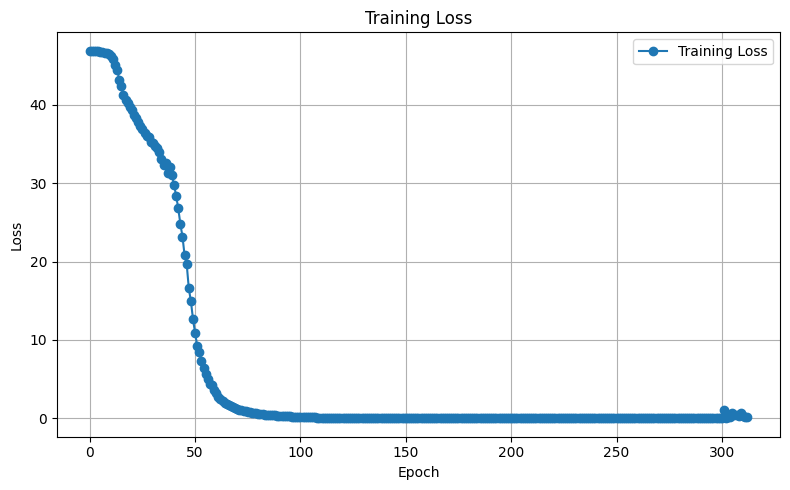

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(_tr_loss, label='Training Loss', marker='o')
#plt.plot(_val_loss, label='Validation Loss', marker='s')

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

def _build_single_scenario_from_batch(batch: dict, config: dict, scen_idx: int = 0):
    processed = preprocess_waymo_batch(batch, config)
    scen = {
        'agents': processed['agents'][scen_idx],
        'roadgraphs': processed['roadgraphs'][scen_idx],
        'traffic_lights': processed['traffic_lights'][scen_idx],
        'labels': processed['labels'][scen_idx],
        'target_agent_pids': processed['target_agent_pids'][scen_idx],
        'index_map': {
            'agents': processed['index_map']['agents'][scen_idx],
            'roadgraphs': processed['index_map']['roadgraphs'][scen_idx],
            'traffic_lights': processed['index_map']['traffic_lights'][scen_idx],
        },
    }
    data = build_pyg_matrix_graph_from_processed(scen, config)
    return scen, data


def animate_one_scenario(
    loader,
    model,
    config,
    scen_idx: int = 0,
    target_rank: int = 0,
    save_path: str | None = None,
    device: str | torch.device = device,
    batchID=0
):
    batch = None
    for b in loader:
        batch = b
        break
    if batch is None:
        print('No data available in loader')
        return None

    if len(trained_on_batch) > 0:
        batch = trained_on_batch[batchID]

    scen, data = _build_single_scenario_from_batch(batch, config, scen_idx=scen_idx)
    target_pids = scen.get('target_agent_pids', [])
    if not target_pids:
        print('No target agents found in scenario; cannot animate predictions.')
        return None

    target_rank = min(max(int(target_rank), 0), len(target_pids) - 1)
    pid_t = int(target_pids[target_rank])

    data = data.to(device)
    num_agent_rows = int(scen['agents'].size(0))

    model = model.to(device)
    model.eval()
    with torch.no_grad():
        pred = model(data.x_dict, data.pids_dict)
        if pred.dim() == 2 and pred.size(1) == config['future_len'] * 2:
            pred = pred.view(-1, config['future_len'], 2)
        assert pred.size(0) >= 1, 'Model produced no target predictions.'
        pred_xy = pred[0].detach().cpu().numpy()  # [F,2]

    labels = scen['labels']  # [T, F, 2]
    gt_xy = labels[target_rank].detach().cpu().numpy() if labels.numel() else np.zeros_like(pred_xy)

    t_ids_all = (batch['state/tracks_to_predict'][0] == 1).nonzero(as_tuple=True)[0]
    if len(t_ids_all) == 0:
        print('No tracks_to_predict==1 in raw batch; cannot determine origin.')
        return None
    ref_tid = int(t_ids_all[0].item())

    ox = float(batch['state/current/x'][0, ref_tid].item()) if config.get('vectornet_normalize', False) else 0.0
    oy = float(batch['state/current/y'][0, ref_tid].item()) if config.get('vectornet_normalize', False) else 0.0

    if 'state/past/x' in batch:
        past_steps = batch['state/past/x'].shape[1] // batch['state/tracks_to_predict'].shape[1]
        past_steps = int(past_steps) if past_steps > 0 else 10
    else:
        past_steps = 10

    tx = batch['state/past/x'][0, pid_t*past_steps:(pid_t+1)*past_steps]
    ty = batch['state/past/y'][0, pid_t*past_steps:(pid_t+1)*past_steps]
    tvalid = batch['state/past/valid'][0, pid_t*past_steps:(pid_t+1)*past_steps] if 'state/past/valid' in batch else torch.ones_like(tx)
    tx = tx[tvalid == 1].detach().cpu().numpy()
    ty = ty[tvalid == 1].detach().cpu().numpy()

    cx = float(batch['state/current/x'][0, pid_t].item())
    cy = float(batch['state/current/y'][0, pid_t].item())
    past_xy = np.column_stack([np.append(tx - ox, cx - ox), np.append(ty - oy, cy - oy)])

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_aspect('equal', adjustable='box')

    past_line, = ax.plot([], [], color='tab:blue', lw=2, label='Past (target)')
    gt_line, = ax.plot([], [], color='tab:green', lw=2, alpha=0.6, label='GT future')
    pred_line, = ax.plot([], [], color='tab:red', lw=2, label='Pred future')

    all_x = np.concatenate([past_xy[:, 0], gt_xy[:, 0], pred_xy[:, 0]]) if gt_xy.size and pred_xy.size else past_xy[:, 0]
    all_y = np.concatenate([past_xy[:, 1], gt_xy[:, 1], pred_xy[:, 1]]) if gt_xy.size and pred_xy.size else past_xy[:, 1]
    pad = 5.0
    xmin, xmax = float(all_x.min()) - pad, float(all_x.max()) + pad
    ymin, ymax = float(all_y.min()) - pad, float(all_y.max()) + pad
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.grid(True, ls='--', alpha=0.3)
    ax.legend(loc='upper right')
    ax.set_title(f'Scenario {batchID} | Target PID {pid_t}')

    def init():
        past_line.set_data(past_xy[:, 0], past_xy[:, 1])
        gt_line.set_data([], [])
        pred_line.set_data([], [])
        return past_line, gt_line, pred_line

    frames = int(config['future_len'])

    def update(frame_idx):
        gt_line.set_data(gt_xy[: frame_idx + 1, 0], gt_xy[: frame_idx + 1, 1])
        pred_line.set_data(pred_xy[: frame_idx + 1, 0], pred_xy[: frame_idx + 1, 1])
        return gt_line, pred_line

    ani = animation.FuncAnimation(fig, update, init_func=init, frames=frames, interval=80, blit=True)

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        try:
            ani.save(save_path, writer='ffmpeg', fps=12)
            print('Saved animation to', save_path)
        except Exception as e:
            print('Saving with ffmpeg failed:', e)
            try:
                gif_path = os.path.splitext(save_path)[0] + '.gif'
                ani.save(gif_path, writer='pillow', fps=12)
                print('Saved animation to', gif_path)
            except Exception as e2:
                print('Saving GIF also failed:', e2)

    plt.close(fig)
    return HTML(ani.to_jshtml())


try:
    html_anim = animate_one_scenario(
        loader=train_loader,
        model=model,
        config=config,
        scen_idx=0,
        target_rank=0,
        save_path='viz_outputs/scenario0_target0.mp4',
        device=device,
        batchID=0,
    )
    html_anim

except Exception as e:
    print('Animation failed:', e)